# Module 5 Learning Activities: Data Exploration and Cleaning using PySpark

This notebook is a beginner-friendly tutorial for the Module 5 practical activities using the **Bank Marketing dataset** (`bank.csv`).

The **code cells are kept exactly the same as the attached `Session5.ipynb` code**. The added text explains what each code block is doing, what the main arguments mean, and how the outputs relate to the learning activity.

## What you will practise

1. Load a CSV file into a PySpark DataFrame.
2. Inspect the schema and preview rows.
3. Calculate simple statistical summaries.
4. Convert small aggregated Spark DataFrames to Pandas for plotting.
5. Create bar charts, histograms and scatter plots.
6. Normalise and standardise variables.
7. Filter rows as a basic data-cleaning operation.

## Before running

Make sure `bank.csv` is in the same folder as this notebook. The Bank Marketing CSV normally uses a semicolon (`;`) as the separator, so the loading code below uses `delimiter=";"`.


## 1. Import libraries

This first cell imports the tools used in the notebook:

- `SparkSession` is the entry point for working with Spark DataFrames.
- `functions as func` gives access to Spark built-in functions such as `mean`, `stddev`, `max`, `min` and aggregation functions.
- `IntegerType` and `DoubleType` are Spark data types. They are imported here for possible type conversion, although this notebook mainly relies on schema inference.


In [1]:
#Import Libraries

from pyspark.sql import SparkSession

# Create Spark Context
from pyspark.sql import functions as func # To use 'sum', 'count', and other functions
from pyspark.sql.types import IntegerType, DoubleType

## 2. Pandas and PySpark

PySpark is designed for distributed data processing. Pandas is simpler and convenient for small data tables and plotting.

A common workflow in beginner notebooks is:

1. Use **PySpark** to load, filter, group and summarise the data.
2. Convert a small result table to **Pandas** using `.toPandas()`.
3. Use Pandas or Matplotlib to draw simple plots.

This is why the notebook imports Pandas as well.


In [2]:
import pandas as pd # Python library to manage dataframes, similar as PySpark

## 3. Create a Spark session

`SparkSession.builder.getOrCreate()` starts a Spark session if one does not already exist.

- `builder` prepares the Spark application configuration.
- `getOrCreate()` either creates a new session or reuses the existing one.

After this cell runs, the variable `spark` is used to read data and create Spark DataFrames.


In [3]:
spark = SparkSession.builder.getOrCreate()

## 4. Load the Bank Marketing dataset

### Download the dataset

The dataset is stored as a zip file.  
The next two commands download and unzip it.

- `wget` downloads the file from the internet.
- `-O bank.zip` saves it with the name `bank.zip`.
- `unzip -o` extracts the file and overwrites old extracted files if they already exist.

In [4]:
!wget -O bank.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip
!unzip -o bank.zip

--2026-06-28 13:21:55--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank.zip’

bank.zip                [ <=>                ] 565.47K  --.-KB/s    in 0.05s   

2026-06-28 13:21:55 (11.1 MB/s) - ‘bank.zip’ saved [579043]

Archive:  bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


Check that `bank.csv` is available in the current working folder.

In [5]:
!ls

bank.csv  bank-full.csv  bank-names.txt  bank.zip  sample_data


This cell reads `bank.csv` into a Spark DataFrame called `bank_data`.

Important arguments:

- `.option('header','true')`: tells Spark that the first row contains column names.
- `.options(delimiter=";")`: tells Spark that values are separated by semicolons, not commas.
- `.csv('bank.csv', inferSchema=True)`: reads the CSV file and asks Spark to automatically infer column data types.
- `.show()`: displays the first rows in a tabular format.

`inferSchema=True` is convenient for beginners because Spark guesses whether each column is integer, double, string, etc. For production work, defining the schema manually is often safer.

In [6]:
bank_data = spark.read.option('header','true').options(delimiter=";").csv('bank.csv', inferSchema=True)
bank_data.show()

# NOTE:
# What is inferSchema=True???
# Infer schema will automatically guess the data types for each field. If we set this option to TRUE, the API will read some sample records from the file to infer the schema. If we want to set this value to false, we must specify a schema explicitly

+---+-------------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|          job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-------------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30|   unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|     services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35|   management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30|   management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|  blue-collar|married|secondary|     no|      0|    yes|  no| unknown| 

## 5. Inspect the DataFrame structure

`printSchema()` shows the column names and inferred data types. This is important because the learning activity asks us to calculate statistics for numeric variables.


In [7]:
# Showing the type of each column

bank_data.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



## 6. Preview the first rows

`head(5)` returns the first five rows as Python Row objects. This is useful for a quick check of the raw values.

Compared with `.show()`, `head()` returns rows to Python, while `.show()` prints a table-like output.


In [8]:
# Showing the first 5 rows of data

bank_data.head(5)

[Row(age=30, job='unemployed', marital='married', education='primary', default='no', balance=1787, housing='no', loan='no', contact='cellular', day=19, month='oct', duration=79, campaign=1, pdays=-1, previous=0, poutcome='unknown', y='no'),
 Row(age=33, job='services', marital='married', education='secondary', default='no', balance=4789, housing='yes', loan='yes', contact='cellular', day=11, month='may', duration=220, campaign=1, pdays=339, previous=4, poutcome='failure', y='no'),
 Row(age=35, job='management', marital='single', education='tertiary', default='no', balance=1350, housing='yes', loan='no', contact='cellular', day=16, month='apr', duration=185, campaign=1, pdays=330, previous=1, poutcome='failure', y='no'),
 Row(age=30, job='management', marital='married', education='tertiary', default='no', balance=1476, housing='yes', loan='yes', contact='unknown', day=3, month='jun', duration=199, campaign=4, pdays=-1, previous=0, poutcome='unknown', y='no'),
 Row(age=59, job='blue-coll

# Activity 1: Statistical and visual data exploration

The first learning activity asks you to explore the data statistically and visually. The following sections follow the attached notebook code and explain each step.


## Task 1: Basic statistics for numeric variables

The first method uses Spark's `.describe()` function. It calculates common summary statistics for selected numeric columns:

- `count`: number of non-null values
- `mean`: average value
- `stddev`: standard deviation
- `min`: minimum value
- `max`: maximum value

The selected columns here are `age`, `balance`, `day`, `duration`, `pdays`, and `previous`.


In [9]:
bank_data.select('age', 'balance', 'day', 'duration', 'pdays', 'previous').describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|               age|           balance|               day|          duration|             pdays|          previous|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|              4521|              4521|              4521|              4521|              4521|              4521|
|   mean| 41.17009511170095|1422.6578190665782|15.915284229152842|263.96129174961294|39.766644547666445|0.5425790754257908|
| stddev|10.576210958711263|3009.6381424673395| 8.247667327229934|259.85663262468216|100.12112444301656|1.6935623506071211|
|    min|                19|             -3313|                 1|                 4|                -1|                 0|
|    max|                87|             71188|                31|              3025|               871|                25|
+-------

## Task 1 continued: individual aggregation functions

The next cells demonstrate how to calculate one statistic at a time for the `age` column.

`func.stddev('age')` applies Spark's standard deviation function to the `age` column.


In [10]:
bank_data.select(func.stddev('age')).show()

+------------------+
|       stddev(age)|
+------------------+
|10.576210958711263|
+------------------+



`func.mean('age')` calculates the average value of the `age` column.


In [11]:
bank_data.select(func.mean('age')).show()

+-----------------+
|         avg(age)|
+-----------------+
|41.17009511170095|
+-----------------+



`func.max('age')` returns the maximum value of the `age` column.


In [12]:
bank_data.select(func.max('age')).show()

+--------+
|max(age)|
+--------+
|      87|
+--------+



`func.min('age')` returns the minimum value of the `age` column.


In [13]:
bank_data.select(func.min('age')).show()

+--------+
|min(age)|
+--------+
|      19|
+--------+



This cell calculates the mean for every numeric column using a Python list comprehension.

The key idea is:

- `numeric_cols` extracts only the column names that are numerical (int or double) to avoid errors with text columns.
- `[func.mean(c) for c in numeric_cols]` creates a list of mean calculations for those specific columns.
- `.select(...)` asks Spark to compute them.
- `.first()` returns the result as a single Row object.

In [15]:
numeric_cols = [col_name for col_name, col_type in bank_data.dtypes if col_type in ('int', 'double')]
bank_data.select([func.mean(c) for c in numeric_cols]).first()

Row(avg(age)=41.17009511170095, avg(balance)=1422.6578190665782, avg(day)=15.915284229152842, avg(duration)=263.96129174961294, avg(campaign)=2.793629727936297, avg(pdays)=39.766644547666445, avg(previous)=0.5425790754257908)

## Task 2: Bar graph for `previous`

The attached code groups the data by `job`, then sums the `previous` values for each job group.

Conceptually:

- `groupBy('job')`: creates one group for each job category.
- `.sum()`: calculates sums for numeric columns within each job group.
- `.orderBy("sum(previous)", ascending=False)`: sorts the groups from highest to lowest total `previous` value.

This creates a small summary table that can be plotted as a bar chart.


In [16]:
# Create a new dataframe in which the rows are groups based on the distict values of 'job' column
df = bank_data.groupBy('job').sum().orderBy("sum(previous)", ascending=False)
df.head(10)

[Row(job='management', sum(age)=39284, sum(balance)=1712154, sum(day)=15751, sum(duration)=252460, sum(campaign)=2881, sum(pdays)=39698, sum(previous)=532),
 Row(job='blue-collar', sum(age)=37988, sum(balance)=1026563, sum(day)=14646, sum(duration)=263141, sum(campaign)=2693, sum(pdays)=39345, sum(previous)=467),
 Row(job='technician', sum(age)=30313, sum(balance)=1022205, sum(day)=12429, sum(duration)=193673, sum(campaign)=2098, sum(pdays)=30156, sum(previous)=443),
 Row(job='admin.', sum(age)=18968, sum(balance)=586380, sum(day)=7803, sum(duration)=112172, sum(campaign)=1258, sum(pdays)=23897, sum(previous)=308),
 Row(job='services', sum(age)=16084, sum(balance)=460350, sum(day)=6470, sum(duration)=109457, sum(campaign)=1177, sum(pdays)=15167, sum(previous)=185),
 Row(job='retired', sum(age)=14230, sum(balance)=533414, sum(day)=3578, sum(duration)=65701, sum(campaign)=567, sum(pdays)=8067, sum(previous)=136),
 Row(job='self-employed', sum(age)=7586, sum(balance)=254811, sum(day)=2961

### 🛠️ How `groupBy` and `.sum()` Work

When you run `bank_data.groupBy('job').sum()`, Spark performs a process often called **Split-Apply-Combine**. Here is a simplified diagram of how it handles the `previous` column:

```mermaid
graph TD
    subgraph "1. Original Data (Split)"
    D1[Row 1: Admin, prev: 2]
    D2[Row 2: Sales, prev: 1]
    D3[Row 3: Admin, prev: 3]
    D4[Row 4: Sales, prev: 5]
    end

    subgraph "2. Grouping (Shuffle)"
    G1[Group: Admin <br/> values: 2, 3]
    G2[Group: Sales <br/> values: 1, 5]
    end

    subgraph "3. Aggregation (Apply/Combine)"
    A1[Admin Sum: 2 + 3 = 5]
    A2[Sales Sum: 1 + 5 = 6]
    end

    D1 & D3 --> G1
    D2 & D4 --> G2
    G1 --> A1
    G2 --> A2
```

#### The 3 Steps:
1.  **Split**: Spark looks at the `job` column and identifies all the unique categories (e.g., 'management', 'technician').
2.  **Shuffle (Grouping)**: Spark moves data across the cluster so that all rows belonging to the same job are handled together.
3.  **Combine (sum)**: For each group, Spark goes through all the numeric columns and adds the values together.

**Note:** This is why the output column name changes from `previous` to `sum(previous)`—to show that the value now represents a total for that category rather than a single record.

### Plotting method 1: Pandas bar chart

Spark itself is not mainly a plotting library. A simple beginner approach is to convert the small grouped result to Pandas and use Pandas plotting.

- `.toPandas()` converts the Spark DataFrame to a Pandas DataFrame.
- `.plot.bar(...)` creates a bar chart.
- `x='job'` uses the job categories on the x-axis.
- `y='sum(previous)'` uses the total previous-contact counts on the y-axis.

Only convert small summary tables to Pandas. Do not convert a very large Spark DataFrame to Pandas.


<Axes: xlabel='job'>

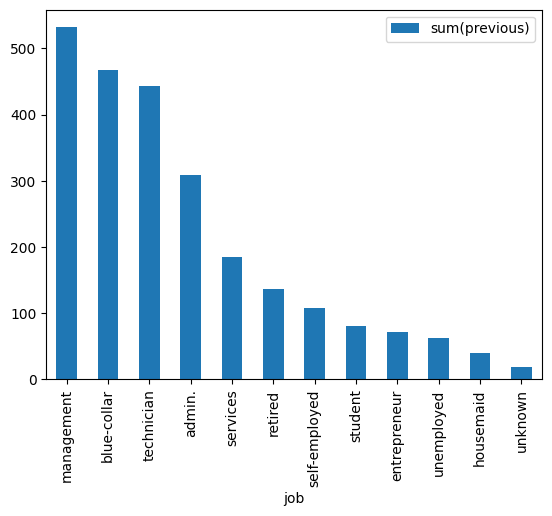

In [17]:
# Convert the PySpark dataframe to Pandas dataframe ( to be able to use the Pandas chart drawing functionality)

df.toPandas().plot.bar(x='job', y='sum(previous)')

### Plotting method 2: Matplotlib bar chart

This cell shows the same idea using Matplotlib.

Important arguments:

- `plt.bar(...)`: draws the bar chart.
- `df_pan['job']`: provides the x-axis categories.
- `df_pan['sum(previous)']`: provides the bar heights.
- `width=0.5`: controls bar width.
- `color="orange"`: sets the bar colour.
- `plt.xticks(rotation = 90)`: rotates labels so job names are easier to read.


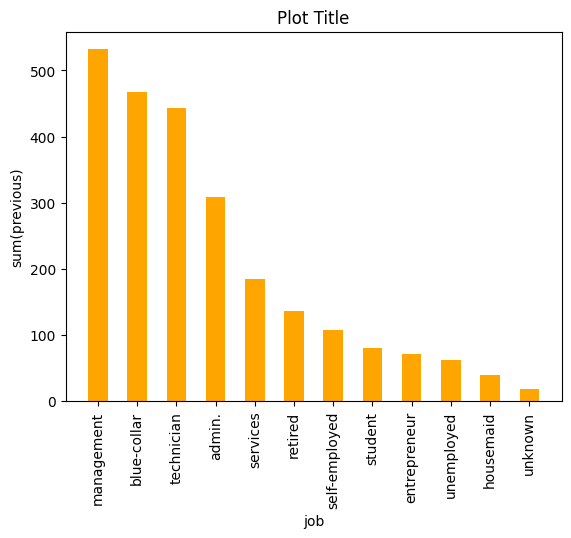

In [18]:
# Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.

import matplotlib.pyplot as plt

# Create a bar chart using Matplotlib
df_pan = df.toPandas() #Convert the PySpark dataframe to Pandas dataframe

plt.bar(df_pan['job'], df_pan['sum(previous)'], width=0.5, color="orange")

# Set the chart title and labels
plt.title('Plot Title')
plt.xlabel('job')
plt.ylabel('sum(previous)')

plt.xticks(rotation = 90)

plt.show()

## Task 3: Normalised bar graph for `previous`

Normalisation rescales values to a common range, usually 0 to 1.

The attached code applies **min-max normalisation** to the `sum(previous)` column after converting the grouped result to Pandas.

Formula:

$$
\text{Normalized Value} = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

After normalisation:

- the smallest value becomes 0
- the largest value becomes 1
- all other values are between 0 and 1

### Step-by-step Normalisation
In the following cell, we:
1. Convert our grouped summary to a Pandas DataFrame.
2. Apply the min-max formula to the `sum(previous)` column.
3. Store the result in a new column called `sum(previous)_norm`.

In [19]:
df_result = df.toPandas()
df_result["sum(previous)_norm"] = (df_result["sum(previous)"] - df_result["sum(previous)"].min()) / (df_result["sum(previous)"].max()-df_result["sum(previous)"].min())

Display the Pandas DataFrame after adding the normalised column `sum(previous)_norm`.


In [20]:
df_result

,job,sum(age),sum(balance),sum(day),sum(duration),sum(campaign),sum(pdays),sum(previous),sum(previous)_norm
0,management,39284,1712154,15751,252460,2881,39698,532,1.000000
1,blue-collar,37988,1026563,14646,263141,2693,39345,467,0.873294
2,technician,30313,1022205,12429,193673,2098,30156,443,0.826511
3,admin.,18968,586380,7803,112172,1258,23897,308,0.563353
4,services,16084,460350,6470,109457,1177,15167,185,0.323587
5,retired,14230,533414,3578,65701,567,8067,136,0.228070
6,self-employed,7586,254811,2961,48335,600,5171,108,0.173489
7,student,2253,129681,1377,20890,201,3840,81,0.120858
8,entrepreneur,7058,276381,2563,47960,435,5422,72,0.103314
9,unemployed,5236,139446,2060,38562,343,4688,62,0.083821


Create a bar chart using the normalised version of `sum(previous)`. This keeps the relative pattern but places the values on a 0–1 scale.


### Note on Pandas for Calculations
In the next cell, we use Pandas syntax `df_result['column'].min()` because we have already converted our small summary table into a Pandas DataFrame. While Spark can also do this, using Pandas for small-scale math like this is often more intuitive for beginners.

<Axes: xlabel='job'>

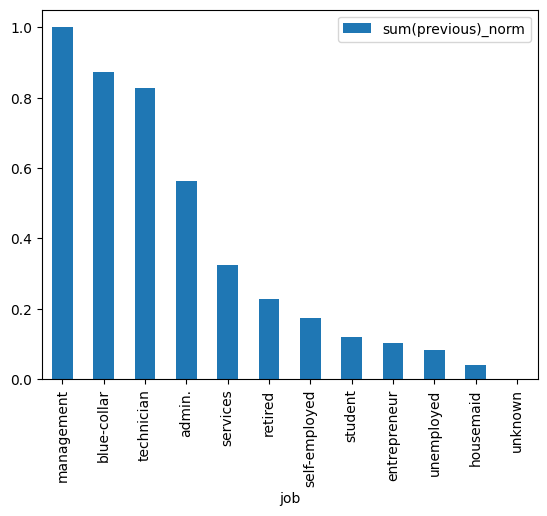

In [21]:
df_result.plot.bar(x='job', y='sum(previous)_norm')

## Standardisation using z-score

Standardisation transforms values so that the transformed column has approximately:

- mean = 0
- standard deviation = 1

Formula:

$$
\text{Standardized Value} = \frac{x - \text{mean}(x)}{\text{standard deviation}(x)}
$$

This is useful when comparing variables measured on different scales.

In [22]:
df_result["sum(previous)_std"] = (df_result["sum(previous)"] - df_result["sum(previous)"].mean()) / (df_result["sum(previous)"].std())

Display the Pandas DataFrame after adding the standardised column `sum(previous)_std`.


In [23]:
df_result

,job,sum(age),sum(balance),sum(day),sum(duration),sum(campaign),sum(pdays),sum(previous),sum(previous)_norm,sum(previous)_std
0,management,39284,1712154,15751,252460,2881,39698,532,1.000000,1.779601
1,blue-collar,37988,1026563,14646,263141,2693,39345,467,0.873294,1.426488
2,technician,30313,1022205,12429,193673,2098,30156,443,0.826511,1.296108
3,admin.,18968,586380,7803,112172,1258,23897,308,0.563353,0.562718
4,services,16084,460350,6470,109457,1177,15167,185,0.323587,-0.105481
5,retired,14230,533414,3578,65701,567,8067,136,0.228070,-0.371675
6,self-employed,7586,254811,2961,48335,600,5171,108,0.173489,-0.523785
7,student,2253,129681,1377,20890,201,3840,81,0.120858,-0.670463
8,entrepreneur,7058,276381,2563,47960,435,5422,72,0.103314,-0.719356
9,unemployed,5236,139446,2060,38562,343,4688,62,0.083821,-0.773681


Create a bar chart for the standardised values. Values above 0 are above average; values below 0 are below average.


<Axes: xlabel='job'>

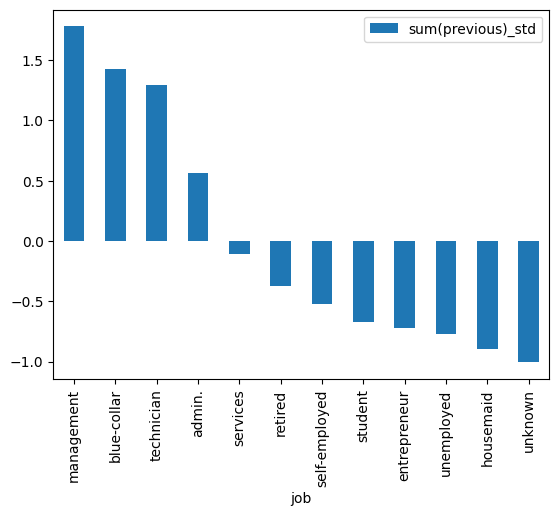

In [24]:
df_result.plot.bar(x='job', y='sum(previous)_std')

Check the mean of the standardised column. It should be very close to 0.


In [25]:
df_result["sum(previous)_std"].mean()

np.float64(5.551115123125783e-17)

Check the standard deviation of the standardised column. It should be close to 1.


In [26]:
df_result["sum(previous)_std"].std()

1.0

## Task 4: Histogram of `age`

A histogram shows the distribution of a numeric variable.

This cell:

1. Selects the `age` column from the Spark DataFrame.
2. Converts that one-column Spark DataFrame to Pandas.
3. Uses Pandas `.hist()` to draw a histogram.

The histogram helps answer questions such as: What ages are common? Is the distribution skewed? Are there unusual values?


array([[<Axes: title={'center': 'age'}>]], dtype=object)

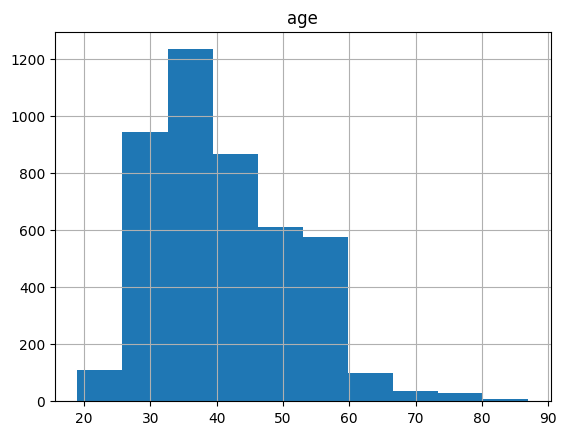

In [27]:
df = bank_data.select('age') # Selecting the column 'age'
df.toPandas().hist(column='age') # Converting the dataframe to Pandas and then draw a histogram

## Task 5: Histogram of normalised `age`

This cell applies min-max normalisation to the `age` column.

The new column `age_norm` stores the normalised values. The distribution shape is the same as `age`, but the x-axis scale changes from actual age values to a 0–1 range.


### Why convert to Pandas here?
We convert the `age` column to Pandas first because:
1. The dataset size for a single column is small enough for your computer's memory.
2. Pandas provides very simple 'one-liner' formulas for min-max scaling that are easy to read.

In [28]:
df_result = df.toPandas()
df_result["age_norm"] = (df_result["age"] - df_result["age"].min()) / (df_result["age"].max()-df_result["age"].min())
df_result

,age,age_norm
0,30,0.161765
1,33,0.205882
2,35,0.235294
3,30,0.161765
4,59,0.588235
...,...,...
4516,33,0.205882
4517,57,0.558824
4518,57,0.558824
4519,28,0.132353


Draw a histogram of `age_norm` to visualise the normalised age distribution.


array([[<Axes: title={'center': 'age_norm'}>]], dtype=object)

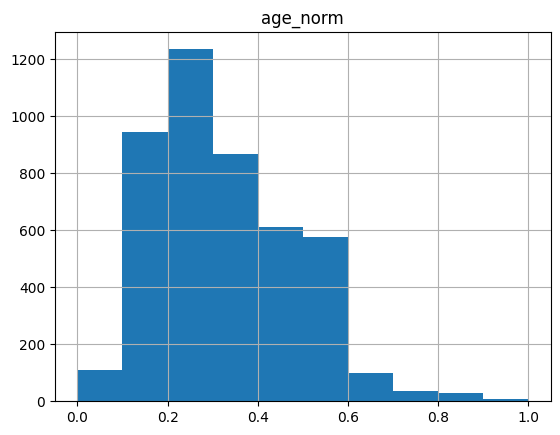

In [29]:
df_result.hist(column='age_norm')

## Task 6: Grouping and bar chart related to age

The attached code groups the data by `job` and calculates the average `age` for each job category.

Important functions:

- `groupBy('job')`: creates job groups.
- `.agg(func.mean('age'))`: calculates the mean age in each job group.
- `.orderBy('avg(age)', ascending=False)`: sorts job groups by average age.
- `.plot.bar(...)`: draws a bar chart after conversion to Pandas.

Use this chart to discuss how age varies across employment categories.


<Axes: xlabel='job'>

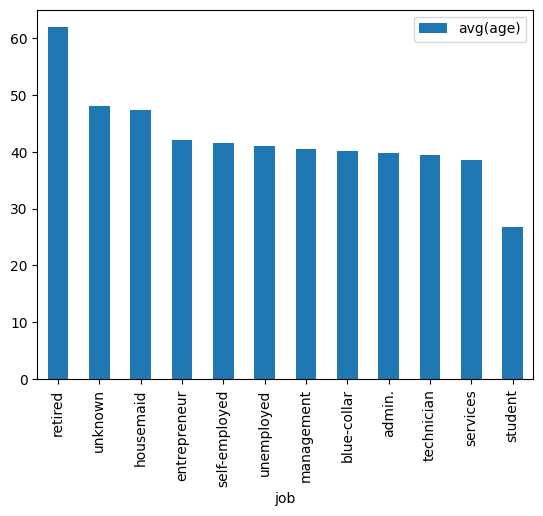

In [30]:
df=bank_data.groupBy('job').agg(func.mean('age')).orderBy('avg(age)', ascending=False)
df.toPandas().plot.bar(x='job', y='avg(age)')

## Task 7: Scatter plot of `age` and `balance`

A scatter plot helps us inspect the relationship between two numeric variables.

This code selects `age` and `balance`, converts the two-column DataFrame to Pandas, and draws a scatter plot.

Interpretation questions:

- Do older customers tend to have higher balances?
- Are there extreme balance values?
- Is the relationship strong, weak, or unclear?


<Axes: xlabel='age', ylabel='balance'>

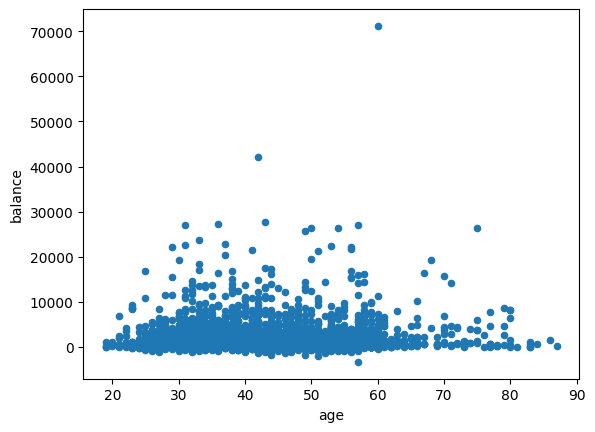

In [31]:
df = bank_data.select('age', 'balance')
df.toPandas().plot.scatter(x='age', y='balance')

# Activity 2: Data cleaning

The second learning activity asks you to remove rows where the `job` column is `unknown` or `unemployed`.

In this scenario, the data owner considers these job values inaccurate, so they should be removed before repeating the exploration.

The following cells demonstrate filtering and cleaning using PySpark.


## Inspect rows where `job` is `unemployed`

`where(...)` filters the DataFrame to keep only rows that satisfy the condition.

Here, the condition is:

`bank_data.job == 'unemployed'`

This is useful before cleaning because we can inspect what will be removed.


In [32]:
# Using 'where' to filter the data
bank_data.where(bank_data.job=='unemployed').show()

+---+----------+--------+---------+-------+-------+-------+----+---------+---+-----+--------+--------+-----+--------+--------+---+
|age|       job| marital|education|default|balance|housing|loan|  contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+----------+--------+---------+-------+-------+-------+----+---------+---+-----+--------+--------+-----+--------+--------+---+
| 30|unemployed| married|  primary|     no|   1787|     no|  no| cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 40|unemployed| married|secondary|     no|    219|    yes|  no| cellular| 17|  nov|     204|       2|  196|       1| failure| no|
| 31|unemployed|  single|  primary|     no|    406|     no|  no| cellular|  4|  feb|     736|       1|   -1|       0| unknown|yes|
| 56|unemployed| married|  primary|     no|   3391|     no|  no| cellular| 21|  apr|     243|       1|   -1|       0| unknown|yes|
| 24|unemployed|  single|secondary|     no|    119|     no|  no|  unknown| 15|  sep

## Inspect rows where `job` is `unknown` or `unemployed`

This cell uses two conditions:

- `bank_data.job == 'unknown'`
- `bank_data.job == 'unemployed'`

The vertical bar `|` means **OR** in PySpark filtering.

So this cell returns rows where the job value is either `unknown` or `unemployed`.


In [33]:
# Using 'and' (&) 'or' (|) to apply multiple conditions
bank_data.where((bank_data.job=='unknown') | (bank_data.job=='unemployed')).show()

+---+----------+--------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|       job| marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+----------+--------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30|unemployed| married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 40|unemployed| married|secondary|     no|    219|    yes|  no|cellular| 17|  nov|     204|       2|  196|       1| failure| no|
| 41|   unknown|  single| tertiary|     no|   1567|     no|  no|cellular|  1|  jul|     291|       2|   -1|       0| unknown| no|
| 31|unemployed|  single|  primary|     no|    406|     no|  no|cellular|  4|  feb|     736|       1|   -1|       0| unknown|yes|
| 56|unemployed| married|  primary|     no|   3391|     no|  no|cellular| 21|  apr|     24

## Count total rows before cleaning

`.count()` returns the number of rows in the DataFrame.

This gives the original dataset size before removing any records.


In [34]:
bank_data.count()

4521

## Count rows that will be removed

This cell counts how many rows have `job` equal to `unknown` or `unemployed`.

You can compare this number with the total row count to understand the scale of the cleaning operation.


In [35]:
bank_data.where((bank_data.job=='unknown') | (bank_data.job=='unemployed')).count()

166

## Remove unwanted rows

This cell creates a cleaned DataFrame named `df_cleaned`.

The condition keeps only rows where:

- `job` is not `unknown`, and
- `job` is not `unemployed`

The ampersand `&` means **AND** in PySpark filtering.


In [36]:
df_cleaned = bank_data.where((bank_data.job!='unknown') & (bank_data.job!='unemployed'))

## Count rows after cleaning

This count should be smaller than the original count because rows with `unknown` and `unemployed` jobs have been removed.


In [37]:
df_cleaned.count()

4355

### Summary of Cleaning Impact
It is good practice to explicitly state how many records were removed during your cleaning process. In this case, we removed rows where the job was 'unknown' or 'unemployed'.

In [40]:
original_count = bank_data.count()
cleaned_count = df_cleaned.count()
removed_count = original_count - cleaned_count

print(f"Original Records: {original_count}")
print(f"Cleaned Records:  {cleaned_count}")
print(f"Records Removed:  {removed_count} ({round(removed_count/original_count*100, 2)}% of data)")

Original Records: 4521
Cleaned Records:  4355
Records Removed:  166 (3.67% of data)


## Check duplicated rows using Pandas

This cell converts the Spark DataFrame to Pandas and checks for duplicated rows.

- `df.duplicated()` returns `True` for rows that are duplicates.
- `df[df.duplicated()]` filters the Pandas DataFrame to show only duplicated rows.

Again, only use `.toPandas()` when the data is small enough to fit in memory.


In [38]:
df = bank_data.toPandas()
duplicated_rows = df[df.duplicated()]
print(duplicated_rows)


Empty DataFrame
Columns: [age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome, y]
Index: []


## Save the cleaned data

`df_cleaned.write.csv("bank_data_cleaned.csv")` writes the cleaned Spark DataFrame to a folder called `bank_data_cleaned.csv`.

Important note for beginners: Spark usually writes a folder containing one or more `part-...csv` files, not a single CSV file like Excel does.

For the learning activity discussion, compare the original dataset results against the cleaned dataset results and describe how removing `unknown` and `unemployed` job rows affects the summary statistics and plots.


In [39]:
df_cleaned.write.csv("bank_data_cleaned.csv")

# Discussion forum guide

When writing your forum post, focus on interpretation rather than only showing outputs.

Possible points to discuss:

- What do the mean, median and standard deviation suggest about the numeric variables?
- Is `age` evenly distributed, skewed, or concentrated in a specific range?
- Which job groups show higher total values of `previous` contact?
- Does the scatter plot suggest any clear relationship between `age` and `balance`?
- After cleaning, how many rows were removed?
- Did the cleaning operation noticeably change the statistics or plots?

---

## Summary of workflow
1. **Load**: Use Spark to read big datasets.
2. **Transform**: Use Spark `.where()` or `.groupBy()` to process data.
3. **Visualise**: Use `.toPandas()` to bring small summary tables into memory for plotting with Matplotlib or Pandas.